In [1]:
import pandas as pd
import numpy as np

melb_data1 = pd.read_csv('melb_data_ps.csv')
melb_df = melb_data1.copy()

melb_df.drop(['index','Coordinates'],axis=1,inplace=True)
total_rooms = melb_df['Rooms'] + melb_df['Bedroom'] + melb_df['Bathroom']
melb_df['MeanRoomsArea'] = melb_df['BuildingArea'] / total_rooms

diff_area = melb_df['BuildingArea'] - melb_df['Landsize']
sum_area = melb_df['BuildingArea'] + melb_df['Landsize']
melb_df['AreaRatio'] = diff_area/sum_area

melb_df['Date'] = pd.to_datetime(melb_df['Date'], dayfirst=True)
years_sold = melb_df['Date'].dt.year
melb_df['MonthSale'] = melb_df['Date'].dt.month
melb_df['MonthSale'].value_counts(normalize=True)
melb_df['AgeBuilding'] = melb_df['Date'].dt.year - melb_df['YearBuilt']

melb_df = melb_df.drop('YearBuilt', axis=1)

melb_df['WeekdaySale'] = melb_df['Date'].dt.dayofweek
melb_df['WeekdaySale'].value_counts(normalize=True) * 100
weekend_count = melb_df['WeekdaySale'].value_counts()[5] + melb_df['WeekdaySale'].value_counts()[6]
# (f"Percentage of sales on weekends: {weekend_count / len(melb_df) * 100:.2f}%")

def get_street_type(address):
    exclude_list = ['N', 'S', 'E', 'W']
    address_list = address.split(' ')
    street_type = address_list[-1]
    if street_type in exclude_list:
        street_type = address_list[-2]
    return street_type
# melb_df['StreetType'] = melb_df['Address'].apply(get_street_type)
# melb_df['StreetType'].value_counts().head(10)

street_types = melb_df['Address'].apply(get_street_type)
popular_street_types = street_types.value_counts().nlargest(10).index
melb_df['StreetType'] = street_types.apply(lambda x: x if x in popular_street_types else 'Other')
# melb_df['StreetType'].value_counts()
# melb_df['StreetType'] = street_types.apply(lambda x: x if x in popular_street_types else 'other')
# display(melb_df['StreetType'])
melb_df = melb_df.drop('Address', axis=1)

melb_df['Weekend'] = melb_df['Date'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)

melb_df['Suburb'] = melb_df['Suburb'].astype('object')
melb_df['SellerG'] = melb_df['SellerG'].astype('category')

cols_to_exclude = ['Date', 'Rooms', 'Bedroom', 'Bathroom', 'Car'] # список столбцов, которые мы не берём во внимание
max_unique_count = 150 # задаём максимальное число уникальных категорий
for col in melb_df.columns: # цикл по именам столбцов
    if melb_df[col].nunique() < max_unique_count and col not in cols_to_exclude: # проверяем условие
        melb_df[col] = melb_df[col].astype('category') # преобразуем тип столбца
#display(melb_df.info())

# (melb_df['Regionname'].cat.categories)
# display(melb_df['Regionname'].cat.codes)

melb_df['Type'] = melb_df['Type'].cat.rename_categories({
    'u': 'unit',
    't': 'townhouse',
    'h': 'house'
})
# display(melb_df['Type'])


popular_suburbs = melb_df['Suburb'].value_counts().nlargest(119).index
melb_df['Suburb'] = melb_df['Suburb'].apply(lambda x: x if x in popular_suburbs else 'Other')
melb_df['Suburb'] = melb_df['Suburb'].astype('category')
#display(melb_df['Suburb'].value_counts())


#melb_df.info()

In [2]:
melb_df1 = pd.read_csv('melb_data_fe.csv')
melb_df = melb_df1.copy()

melb_df['Date'] = pd.to_datetime(melb_df['Date'])
melb_df_quarter = melb_df['Date'].dt.quarter
# melb_df_quarter.value_counts(normalize=True) * 100
melb_df_quarter.value_counts(dropna=False).iloc[1]

for col in melb_df.columns:
    if melb_df[col].nunique() < max_unique_count and col not in cols_to_exclude:
        melb_df[col] = melb_df[col].astype('category')

melb_df.sort_values(by=['Distance', 'Price']).loc[::10, ['Distance', 'Price']]


mask1 = melb_df['AreaRatio'] < -0.8
mask2 = melb_df['Type'] == 'townhouse'
mask3 = melb_df['SellerG'] == 'McGrath'
melb_df[mask1 & mask2 & mask3].sort_values(
    by=['Date', 'AreaRatio'],
    ascending=[True, False],
    ignore_index=True
).loc[:, ['Date', 'AreaRatio']]

#Alternative solution is where lead time is not critical, but code readability is more important.
result = melb_df.query(
    "AreaRatio < -0.8 & Type == 'townhouse' & SellerG == 'McGrath'"
).sort_values(
    by=['Date', 'AreaRatio'],
    ascending=[True, False]
).reset_index(drop=True)[['Date', 'AreaRatio']]


mask1 = melb_df['Type'] == 'townhouse'
mask2 = melb_df['Rooms'] > 2
int(melb_df[mask1&mask2].sort_values(
    by=['Rooms', 'MeanRoomsSquare'],
    ascending=[True, False],
    ignore_index=True
).loc[18, 'Price'])

melb_df.groupby('MonthSale')['Price'].agg(
    ['count', 'mean', 'max']
).sort_values(by='count', ascending=False)

melb_df.groupby('Regionname')['SellerG'].agg(
    ['nunique', 'count', lambda x: x.nunique() / x.count() * 100]
)

date1 = pd.to_datetime('2017-05-01')
date2 = pd.to_datetime('2017-09-01')
mask = (date1 <= melb_df['Date']) & (melb_df['Date']<= date2)
melb_df[mask].groupby('SellerG')['Price'].sum().sort_values(ascending=True)

melb_df.pivot_table(
    values='Price',
    index='Rooms',
    columns='Type',
    fill_value=0
)

melb_df.pivot_table(
    values='Price',
    index='Regionname',
    columns='Weekend',
    aggfunc='count'
)

melb_df.pivot_table(
    values='Price',
    index=['Method','Type'],
    columns='Regionname',
    aggfunc='median',
    fill_value=0
)

pivot = melb_df.pivot_table(
    values='Landsize',
    index='Regionname',
    columns='Type',
    aggfunc=['median', 'mean'],
    fill_value=0
)
pivot.columns

mask = pivot['mean']['house'] < pivot['median']['house']
filtered_pivot = pivot[mask]
#display(filtered_pivot)

pivot = melb_df.pivot_table(
    values='BuildingArea',
    index='Type',
    columns='Rooms',
    aggfunc='median',
    fill_value=0
)
#display(pivot)

pivot = melb_df.pivot_table(
    values='Price',
    index='SellerG',
    columns='Type',
    aggfunc='median',
)
max_unit_price = pivot['unit'].max()
#print(pivot[pivot['unit'] == max_unit_price].index[0])












ИСХОДНЫЕ ДАННЫЕ:
Всего записей: 500
Уникальных пригородов: 19

Топ-5 пригородов:
Suburb
Richmond     159
Southbank    119
Fitzroy       91
Carlton       59
Kew           35
Name: count, dtype: int64

ШАГ 1: Топ-5 популярных пригородов:
['Richmond', 'Southbank', 'Fitzroy', 'Carlton', 'Kew']

ШАГ 2: После замены редких на 'Other':
Уникальных значений: 6

Распределение:
Suburb_processed
Richmond     159
Southbank    119
Fitzroy       91
Carlton       59
Other         37
Kew           35
Name: count, dtype: int64

ШАГ 3: Тип данных после преобразования: category


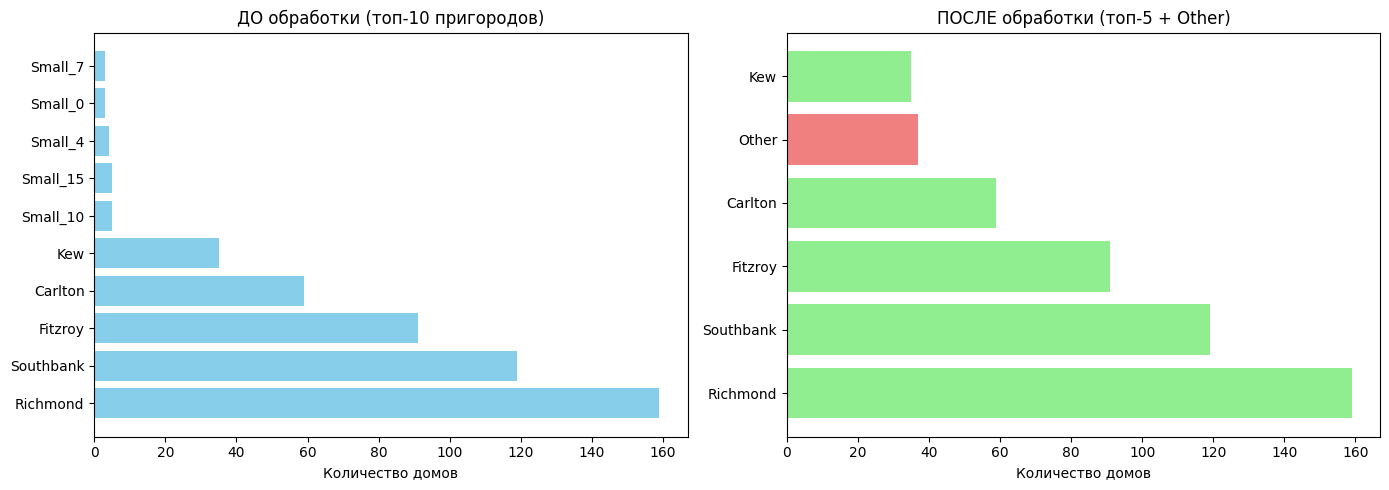

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Создадим пример с данными о домах
np.random.seed(42)

# Генерируем пригороды с разной частотой
suburbs = ['Richmond', 'Southbank', 'Fitzroy', 'Carlton', 'Kew'] + \
          [f'Small_{i}' for i in range(20)]
weights = [100, 80, 60, 40, 20] + [1]*20

melb_df = pd.DataFrame({
    'Suburb': np.random.choice(suburbs, size=500, p=np.array(weights)/sum(weights)),
    'Price': np.random.randint(500000, 2000000, 500)
})

print("ИСХОДНЫЕ ДАННЫЕ:")
print(f"Всего записей: {len(melb_df)}")
print(f"Уникальных пригородов: {melb_df['Suburb'].nunique()}")
print("\nТоп-5 пригородов:")
print(melb_df['Suburb'].value_counts().head())

# Шаг 1: Находим топ-5 популярных (в вашем коде 119)
popular_suburbs = melb_df['Suburb'].value_counts().nlargest(5).index
print(f"\nШАГ 1: Топ-5 популярных пригородов:")
print(list(popular_suburbs))

# Альтернативный способ определения популярных пригородов через частоту
# freq = melb_df['Suburb'].value_counts(normalize=True)
# popular = freq[freq > 0.05].index

# Шаг 2: Заменяем редкие на 'Other'
melb_df['Suburb_processed'] = melb_df['Suburb'].apply(
    lambda x: x if x in popular_suburbs else 'Other'
)
# Шаг 2: Заменяем редкие на 'Other'
melb_df['Suburb_processed'] = melb_df['Suburb'].where(
    melb_df['Suburb'].isin(popular_suburbs), 'Other'
)# альтернативный способ замены, который может быть чуть быстрее

print(f"\nШАГ 2: После замены редких на 'Other':")
print(f"Уникальных значений: {melb_df['Suburb_processed'].nunique()}")
print("\nРаспределение:")
print(melb_df['Suburb_processed'].value_counts())

# Шаг 3: Преобразуем в категорию
melb_df['Suburb_processed'] = melb_df['Suburb_processed'].astype('category')
print(f"\nШАГ 3: Тип данных после преобразования: {melb_df['Suburb_processed'].dtype}")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# До обработки
top10_original = melb_df['Suburb'].value_counts().head(10)
axes[0].barh(range(len(top10_original)), top10_original.values, color='skyblue')
axes[0].set_yticks(range(len(top10_original)))
axes[0].set_yticklabels(top10_original.index)
axes[0].set_title('ДО обработки (топ-10 пригородов)')
axes[0].set_xlabel('Количество домов')

# После обработки
processed_counts = melb_df['Suburb_processed'].value_counts()
axes[1].barh(range(len(processed_counts)), processed_counts.values, 
             color=['lightgreen' if i != 'Other' else 'lightcoral' 
                    for i in processed_counts.index])
axes[1].set_yticks(range(len(processed_counts)))
axes[1].set_yticklabels(processed_counts.index)
axes[1].set_title('ПОСЛЕ обработки (топ-5 + Other)')
axes[1].set_xlabel('Количество домов')

plt.tight_layout()
plt.show()